<a href="https://colab.research.google.com/github/neupra/Bayesian-Statistical-Modelling/blob/main/Hierarchical_(Multilevel)_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2: Hierarchical (Multilevel) Models**


Course: Bayesian Statistics



# Section 1: Setup and Scenario 1 (Hierarchical Normal Model)

In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)
az.style.use("arviz-darkgrid")
%matplotlib inline

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")

PyMC version: 5.28.5
ArviZ version: 0.22.0


#Scenario 1 - Problem Description & Data Generation

## 1. Problem Description (Scenario 1)
We aim to estimate school-level mathematics performance across 8 schools.
Because sample sizes vary across schools, a hierarchical normal model allows us to 'borrow strength'
(partial pooling), providing more robust estimates for smaller schools while avoiding the over-generalization of complete pooling.

## 2. Data Generation
We set true underlying parameters and simulate synthetic student scores.


In [ ]:
# True hyperparameters
TRUE_MU = 75.0      # Overall district mean score
TRUE_TAU = 5.0      # Between-school standard deviation
TRUE_SIGMA = 8.0    # Within-school (student-level) standard deviation

J = 8  # Number of schools
# Varying sample sizes per school (some large, some very small to demonstrate shrinkage)
school_sizes = [10, 45, 12, 80, 8, 50, 15, 60]

# Generate true school-specific means
true_theta = np.random.normal(TRUE_MU, TRUE_TAU, size=J)

school_idx = []
scores = []

for j in range(J):
    # Generate student scores for each school
    student_scores = np.random.normal(true_theta[j], TRUE_SIGMA, size=school_sizes[j])
    scores.extend(student_scores)
    school_idx.extend([j] * school_sizes[j])

# Create DataFrame
df_normal = pd.DataFrame({
    'school_id': school_idx,
    'score': scores
})

print("True School Means:", np.round(true_theta, 2))
print(f"Total simulated students: {len(df_normal)}")
df_normal.groupby('school_id').agg(Sample_Size=('score', 'count'), Sample_Mean=('score', 'mean')).round(2)

True School Means: [77.48 74.31 78.24 82.62 73.83 73.83 82.9  78.84]
Total simulated students: 280


,Sample_Size,Sample_Mean
school_id,,
0,10,73.07
1,45,72.54
2,12,79.86
3,80,82.29
4,8,75.89
5,50,75.51
6,15,82.26
7,60,78.48


#Scenario 1 - Model Formulation & Implementation

## 3. Hierarchical Model Formulation

In [ ]:
"""
Mathematically, the model is specified as:
Score_{i} ~ Normal(theta_{j[i]}, sigma)
theta_{j} ~ Normal(mu, tau)

Priors:
mu ~ Normal(75, 15)
tau ~ HalfNormal(10)
sigma ~ HalfNormal(15)
"""

with pm.Model() as normal_hierarchical_model:
    # Hyper-priors
    mu = pm.Normal("mu", mu=75, sigma=15)
    tau = pm.HalfNormal("tau", sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=15)

    # Latent school-specific effects (Non-centered parameterization to avoid divergences)
    theta_offset = pm.Normal("theta_offset", mu=0, sigma=1, shape=J)
    theta = pm.Deterministic("theta", mu + theta_offset * tau)

    # Likelihood
    observed_scores = pm.Normal("observed_scores", mu=theta[df_normal['school_id'].values], sigma=sigma, observed=df_normal['score'].values)

    # Posterior Sampling
    idata_normal = pm.sample(draws=1500, tune=1000, return_inferencedata=True, random_seed=42)
    # Posterior Predictive Sampling
    pm.sample_posterior_predictive(idata_normal, extend_inferencedata=True, random_seed=42)

Output()

ERROR:pymc.stats.convergence:There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

# Cell 4: Scenario 1 - Convergence Diagnostics & Parameter Recovery

## 4. Posterior Analysis & Convergence Diagnostics
We verify convergence using R-hat values (should be close to 1.0) and Effective Sample Size (ESS).
Then we compare recovered parameters against the true values.


            mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
mu        77.626  1.700  74.504   80.980    1.0     637.0
tau        4.337  1.613   1.886    7.534    1.0     611.0
sigma      8.005  0.332   7.357    8.581    1.0    2230.0
theta[0]  74.430  2.242  70.363   78.838    1.0    2421.0
theta[1]  73.040  1.181  70.965   75.389    1.0    2904.0
theta[2]  79.270  2.013  75.608   83.243    1.0    2472.0
theta[3]  82.041  0.887  80.223   83.622    1.0    2609.0
theta[4]  76.533  2.391  71.978   80.900    1.0    2998.0
theta[5]  75.698  1.088  73.724   77.697    1.0    2973.0
theta[6]  81.197  1.867  77.870   84.766    1.0    2406.0
theta[7]  78.430  0.990  76.603   80.220    1.0    3528.0


/tmp/ipykernel_1361/3426557297.py:7: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


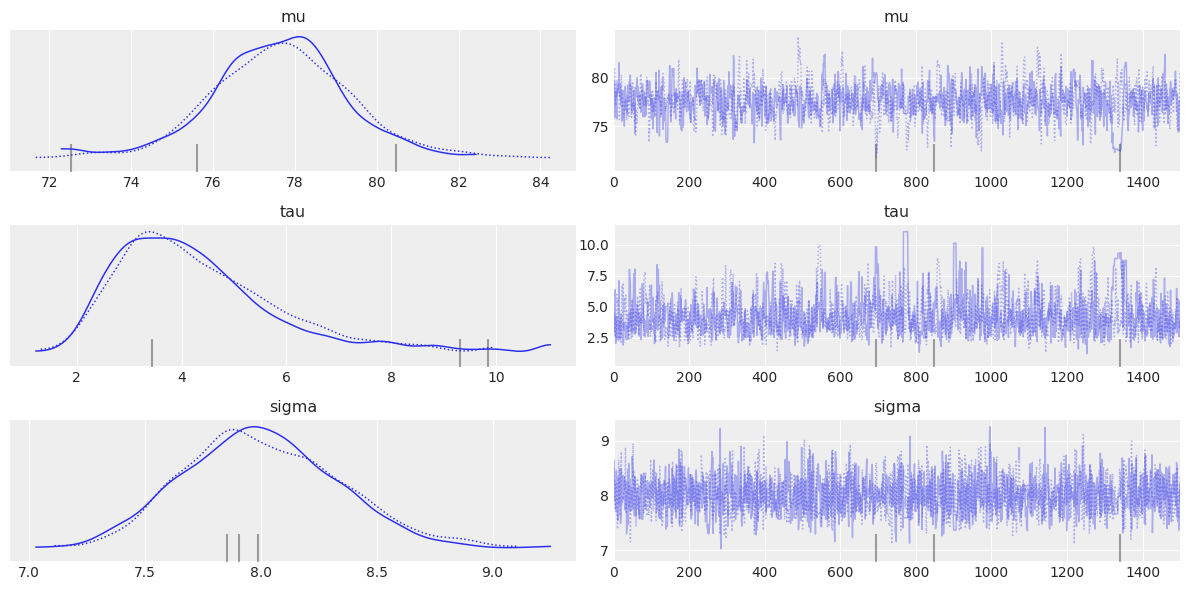


--- Parameter Recovery Evaluation ---
True Mu: 75.0 | Estimated Mu: 77.63
True Tau: 5.0 | Estimated Tau: 4.34
True Sigma: 8.0 | Estimated Sigma: 8.01


In [ ]:
# Display summary statistics for global parameters
summary_normal = az.summary(idata_normal, var_names=["mu", "tau", "sigma", "theta"])
print(summary_normal[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"]])

# Plot Traces to check for mixing
az.plot_trace(idata_normal, var_names=["mu", "tau", "sigma"])
plt.tight_layout()
plt.show()

print(f"\n--- Parameter Recovery Evaluation ---")
print(f"True Mu: {TRUE_MU} | Estimated Mu: {summary_normal.loc['mu', 'mean']:.2f}")
print(f"True Tau: {TRUE_TAU} | Estimated Tau: {summary_normal.loc['tau', 'mean']:.2f}")
print(f"True Sigma: {TRUE_SIGMA} | Estimated Sigma: {summary_normal.loc['sigma', 'mean']:.2f}")

# Cell 5: Scenario 1 - PPC and Shrinkage Analysis

## 5. Posterior Predictive Checks & Interpretations


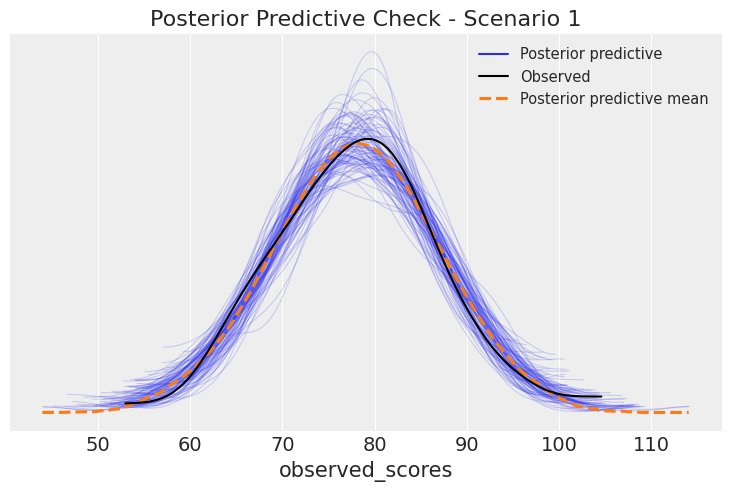

### School Classification Relative to District Average ###
School 0 (N=10): Est. Mean = 74.43 -> BELOW Average (77.63)
School 1 (N=45): Est. Mean = 73.04 -> BELOW Average (77.63)
School 2 (N=12): Est. Mean = 79.27 -> ABOVE Average (77.63)
School 3 (N=80): Est. Mean = 82.04 -> ABOVE Average (77.63)
School 4 (N=8): Est. Mean = 76.53 -> BELOW Average (77.63)
School 5 (N=50): Est. Mean = 75.70 -> BELOW Average (77.63)
School 6 (N=15): Est. Mean = 81.20 -> ABOVE Average (77.63)
School 7 (N=60): Est. Mean = 78.43 -> ABOVE Average (77.63)

### Shrinkage and Partial Pooling Explanation ###
School 4 (N=8): Raw Sample Mean = 75.89 | Hierarchical Estimate = 76.53
School 3 (N=80): Raw Sample Mean = 82.29 | Hierarchical Estimate = 82.04


In [ ]:
# 1. Posterior Predictive Check Plot
az.plot_ppc(idata_normal, num_pp_samples=100)
plt.title("Posterior Predictive Check - Scenario 1")
plt.show()

# 2. Performance Evaluation: Ranking Schools
school_means_est = summary_normal.loc[[f"theta[{i}]" for i in range(J)], "mean"].values
overall_mu_est = summary_normal.loc["mu", "mean"]

print("### School Classification Relative to District Average ###")
for i in range(J):
    status = "ABOVE" if school_means_est[i] > overall_mu_est else "BELOW"
    print(f"School {i} (N={school_sizes[i]}): Est. Mean = {school_means_est[i]:.2f} -> {status} Average ({overall_mu_est:.2f})")

# 3. Shrinkage Demonstration
sample_means = df_normal.groupby('school_id')['score'].mean().values
print("\n### Shrinkage and Partial Pooling Explanation ###")
# Compare School 4 (Small sample size: N=8) vs School 3 (Large sample size: N=80)
for idx in [4, 3]:
    print(f"School {idx} (N={school_sizes[idx]}): Raw Sample Mean = {sample_means[idx]:.2f} | Hierarchical Estimate = {school_means_est[idx]:.2f}")


Notice that School 4 (N=8) shrinks significantly closer to the overall mean (mu) because its small sample size carries high uncertainty. Conversely, School 3 (N=80) changes very little because the empirical data provides strong evidence of its true location.

# Section 2: Scenario 2 (Hierarchical Logistic Model)

#Scenario 2 - Problem Description & Data Generation

## 1. Problem Description (Scenario 2)
We monitor binomial recovery rates across 10 hospitals. Since smaller hospitals suffer from
high variance in raw percentages (e.g., 0% or 100% recovery due to small sample sizes),
a hierarchical logistic model stabilizes these estimates via a shared beta/normal logit distribution.

## 2. Data Generation

In [ ]:
K = 10  # Number of hospitals
hospital_sizes = [15, 120, 8, 200, 12, 150, 22, 90, 14, 110] # Varying patient counts

TRUE_MU_LOGIT = 0.65  # Logit scale baseline recovery tendency (~65.7% baseline probability)
TRUE_TAU_LOGIT = 0.50 # Between-hospital standard deviation on logit scale

# Generate true hospital-specific logit recovery propensities and probabilities
true_alpha = np.random.normal(TRUE_MU_LOGIT, TRUE_TAU_LOGIT, size=K)
true_p = 1 / (1 + np.exp(-true_alpha)) # Inverse logit transformation

# Simulate empirical binomial outcomes (successes)
recovered_patients = np.random.binomial(n=hospital_sizes, p=true_p)

df_logistic = pd.DataFrame({
    'hospital_id': np.arange(K),
    'total_patients': hospital_sizes,
    'recovered': recovered_patients,
    'raw_rate': recovered_patients / hospital_sizes
})

print("True Probabilities per Hospital:\n", np.round(true_p, 3))
df_logistic.round(3)

True Probabilities per Hospital:
 [0.566 0.545 0.744 0.635 0.627 0.413 0.725 0.508 0.664 0.688]


,hospital_id,total_patients,recovered,raw_rate
0,0,15,9,0.600
1,1,120,66,0.550
2,2,8,4,0.500
3,3,200,120,0.600
4,4,12,7,0.583
5,5,150,59,0.393
6,6,22,15,0.682
7,7,90,47,0.522
8,8,14,8,0.571
9,9,110,69,0.627


# Cell 7: Scenario 2 - Model Formulation & Implementation

## 3. Hierarchical Logistic Model Formulation


In [ ]:

"""

Recovered_{j} ~ Binomial(Total_{j}, p_{j})
logit(p_{j}) = alpha_{j}
alpha_{j} ~ Normal(mu_logit, tau_logit)

Priors:
mu_logit ~ Normal(0, 1.5)
tau_logit ~ HalfNormal(1)
"""

with pm.Model() as logistic_hierarchical_model:
    # Hyper-priors on the logit scale
    mu_logit = pm.Normal("mu_logit", mu=0, sigma=1.5)
    tau_logit = pm.HalfNormal("tau_logit", sigma=1)

    # Non-centered parameterization for hospital random effects
    alpha_offset = pm.Normal("alpha_offset", mu=0, sigma=1, shape=K)
    alpha = pm.Deterministic("alpha", mu_logit + alpha_offset * tau_logit)

    # Deterministic transformation back to probability scale
    p = pm.Deterministic("p", pm.math.invlogit(alpha))

    # Likelihood
    observed_recoveries = pm.Binomial("observed_recoveries", n=df_logistic['total_patients'].values, p=p, observed=df_logistic['recovered'].values)

    # Posterior Inference
    idata_logistic = pm.sample(draws=1500, tune=1000, return_inferencedata=True, random_seed=42)
    pm.sample_posterior_predictive(idata_logistic, extend_inferencedata=True, random_seed=42)

Output()

ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


Output()

#Scenario 2 - Convergence Diagnostics & Comparisons

## 4. Posterior Analysis & Convergence Diagnostics


            mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
mu_logit   0.217  0.159  -0.070    0.529    1.0     803.0
tau_logit  0.346  0.145   0.123    0.635    1.0     998.0
p[0]       0.566  0.073   0.425    0.701    1.0    2283.0
p[1]       0.549  0.040   0.476    0.626    1.0    3741.0
p[2]       0.542  0.083   0.385    0.702    1.0    2628.0
p[3]       0.590  0.032   0.526    0.648    1.0    3871.0
p[4]       0.562  0.075   0.419    0.702    1.0    2942.0
p[5]       0.431  0.043   0.358    0.518    1.0    2441.0
p[6]       0.601  0.070   0.471    0.740    1.0    2540.0
p[7]       0.533  0.043   0.452    0.615    1.0    3521.0
p[8]       0.559  0.075   0.415    0.700    1.0    2363.0
p[9]       0.606  0.043   0.531    0.692    1.0    3190.0


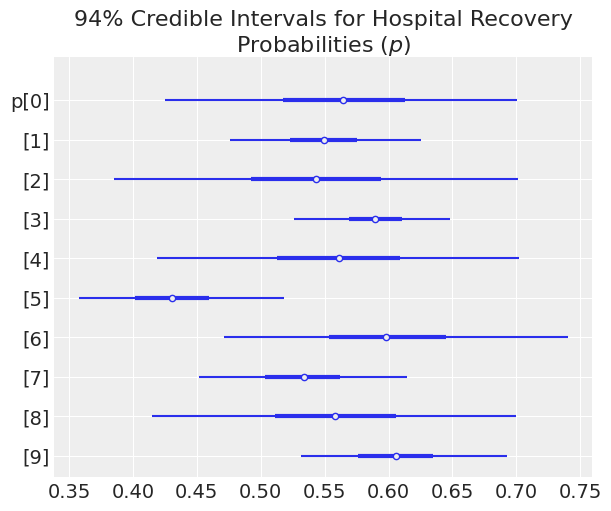

True Logit Mu: 0.65 | Estimated Logit Mu: 0.22
True Logit Tau: 0.5 | Estimated Logit Tau: 0.35


In [ ]:

summary_logistic = az.summary(idata_logistic, var_names=["mu_logit", "tau_logit", "p"])
print(summary_logistic[["mean", "sd", "hdi_3%", "hdi_97%", "r_hat", "ess_bulk"]].head(15))

# Plot Forest Plot for Hospital Probabilities (94% credible intervals)
az.plot_forest(idata_logistic, var_names=["p"], combined=True)
plt.title("94% Credible Intervals for Hospital Recovery Probabilities ($p$)")
plt.grid(True)
plt.show()

# Parameter Recovery Analysis
print(f"True Logit Mu: {TRUE_MU_LOGIT} | Estimated Logit Mu: {summary_logistic.loc['mu_logit', 'mean']:.2f}")
print(f"True Logit Tau: {TRUE_TAU_LOGIT} | Estimated Logit Tau: {summary_logistic.loc['tau_logit', 'mean']:.2f}")

#Scenario 2 - PPC and Partial Pooling Discussion

## 5. Posterior Predictive Checks & Interpretations


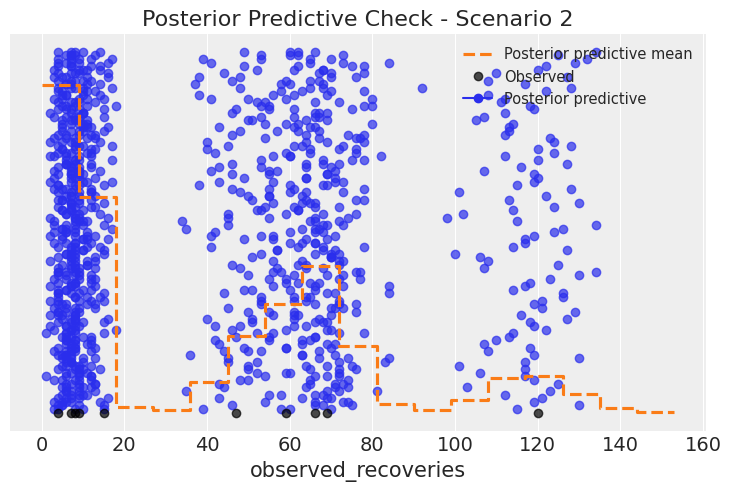

Hospital with HIGHEST recovery probability: Hospital 9 (Est. P = 0.606)
Hospital with LOWEST recovery probability: Hospital 5 (Est. P = 0.431)

### The Role of Partial Pooling in Preventing Extreme Estimates ###
Hospital 2 (N=8): Raw Empirical Rate = 0.500 | Hierarchical Shrinkage Estimate (p) = 0.542
Hospital 3 (N=200): Raw Empirical Rate = 0.600 | Hierarchical Shrinkage Estimate (p) = 0.590


In [ ]:

# Posterior Predictive Check Plot
az.plot_ppc(idata_logistic, num_pp_samples=100, kind="scatter")
plt.title("Posterior Predictive Check - Scenario 2")
plt.show()

# Identify highest and lowest performing hospitals
est_p = summary_logistic.loc[[f"p[{i}]" for i in range(K)], "mean"].values
highest_hosp = np.argmax(est_p)
lowest_hosp = np.argmin(est_p)

print(f"Hospital with HIGHEST recovery probability: Hospital {highest_hosp} (Est. P = {est_p[highest_hosp]:.3f})")
print(f"Hospital with LOWEST recovery probability: Hospital {lowest_hosp} (Est. P = {est_p[lowest_hosp]:.3f})\n")

# Partial Pooling vs Extreme Estimates for Small Hospitals Explanation
print("### The Role of Partial Pooling in Preventing Extreme Estimates ###")
for idx in [2, 3]: # Hospital 2 is very small (N=8), Hospital 3 is very large (N=200)
    print(f"Hospital {idx} (N={hospital_sizes[idx]}): Raw Empirical Rate = {df_logistic['raw_rate'].iloc[idx]:.3f} | Hierarchical Shrinkage Estimate (p) = {est_p[idx]:.3f}")


 If Hospital 2 (N=8) accidentally recorded 2 recoveries out of 8, its raw rate is 0.250. Without hierarchical modeling, we would naively assume this hospital is dangerously inefficient. Partial pooling pulls this extreme estimate toward the collective baseline distribution, protecting the profile of small hospitals from sampling artifacts caused strictly by low sample sizes.